In [13]:
import pandas as pd
import os

print("--- TAHAP 1: LOAD DATA & INSPEKSI AWAL ---")

# 1. Cek & Load File
filename = 'clusteringmidterm.csv'

if os.path.exists(filename):
    df = pd.read_csv(filename)
    print(f"-> Sukses memuat file: {filename}")
elif os.path.exists('clusteringmidterm.csv'):
    df = pd.read_csv('clusteringmidterm.csv')
    print("-> Sukses memuat file: clusteringmidterm.csv")
else:
    raise FileNotFoundError("File CSV tidak ditemukan! Pastikan sudah diupload ke folder yang sama.")

# 2. Lihat Isi Data
print(f"\nDimensi Data: {df.shape}")
print("\n5 Baris Pertama:")
display(df.head())

print("\nInfo Data (Tipe & Missing Values):")
print(df.info())

--- TAHAP 1: LOAD DATA & INSPEKSI AWAL ---
-> Sukses memuat file: clusteringmidterm.csv

Dimensi Data: (8950, 18)

5 Baris Pertama:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12



Info Data (Tipe & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                 

In [14]:
print("--- TAHAP 2: DATA CLEANING ---")

# Pastikan variabel 'df' sudah ada dari Tahap 1
if 'df' not in locals():
    raise ValueError("Variabel 'df' tidak ditemukan! Harap jalankan Tahap 1 terlebih dahulu.")

# 1. BUANG KOLOM YANG TIDAK PERLU (CUST_ID)
if 'CUST_ID' in df.columns:
    df = df.drop('CUST_ID', axis=1)
    print("-> Kolom 'CUST_ID' berhasil dibuang.")
else:
    print("-> Kolom 'CUST_ID' tidak ditemukan (mungkin sudah dibuang sebelumnya).")

# 2. CEK & ISI MISSING VALUES
# Kita cek dulu ada berapa yang kosong
null_counts = df.isnull().sum()
missing_cols = null_counts[null_counts > 0]

if not missing_cols.empty:
    print("\n[Info] Ditemukan Missing Values pada:")
    print(missing_cols)

    # Isi dengan MEDIAN (Nilai tengah)
    # Median lebih aman daripada Mean (rata-rata) karena data keuangan sering punya angka ekstrem
    df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
    df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
    print("-> Missing values telah diisi dengan nilai Median.")
else:
    print("\n[Info] Tidak ada Missing Values yang perlu diisi.")

# 3. VERIFIKASI AKHIR
print(f"\nShape Akhir Data: {df.shape}")
print(f"Total Missing Values: {df.isnull().sum().sum()}")

# Tampilkan 5 baris data bersih
display(df.head())

--- TAHAP 2: DATA CLEANING ---
-> Kolom 'CUST_ID' berhasil dibuang.

[Info] Ditemukan Missing Values pada:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64
-> Missing values telah diisi dengan nilai Median.

Shape Akhir Data: (8950, 17)
Total Missing Values: 0


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


--- TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) ---


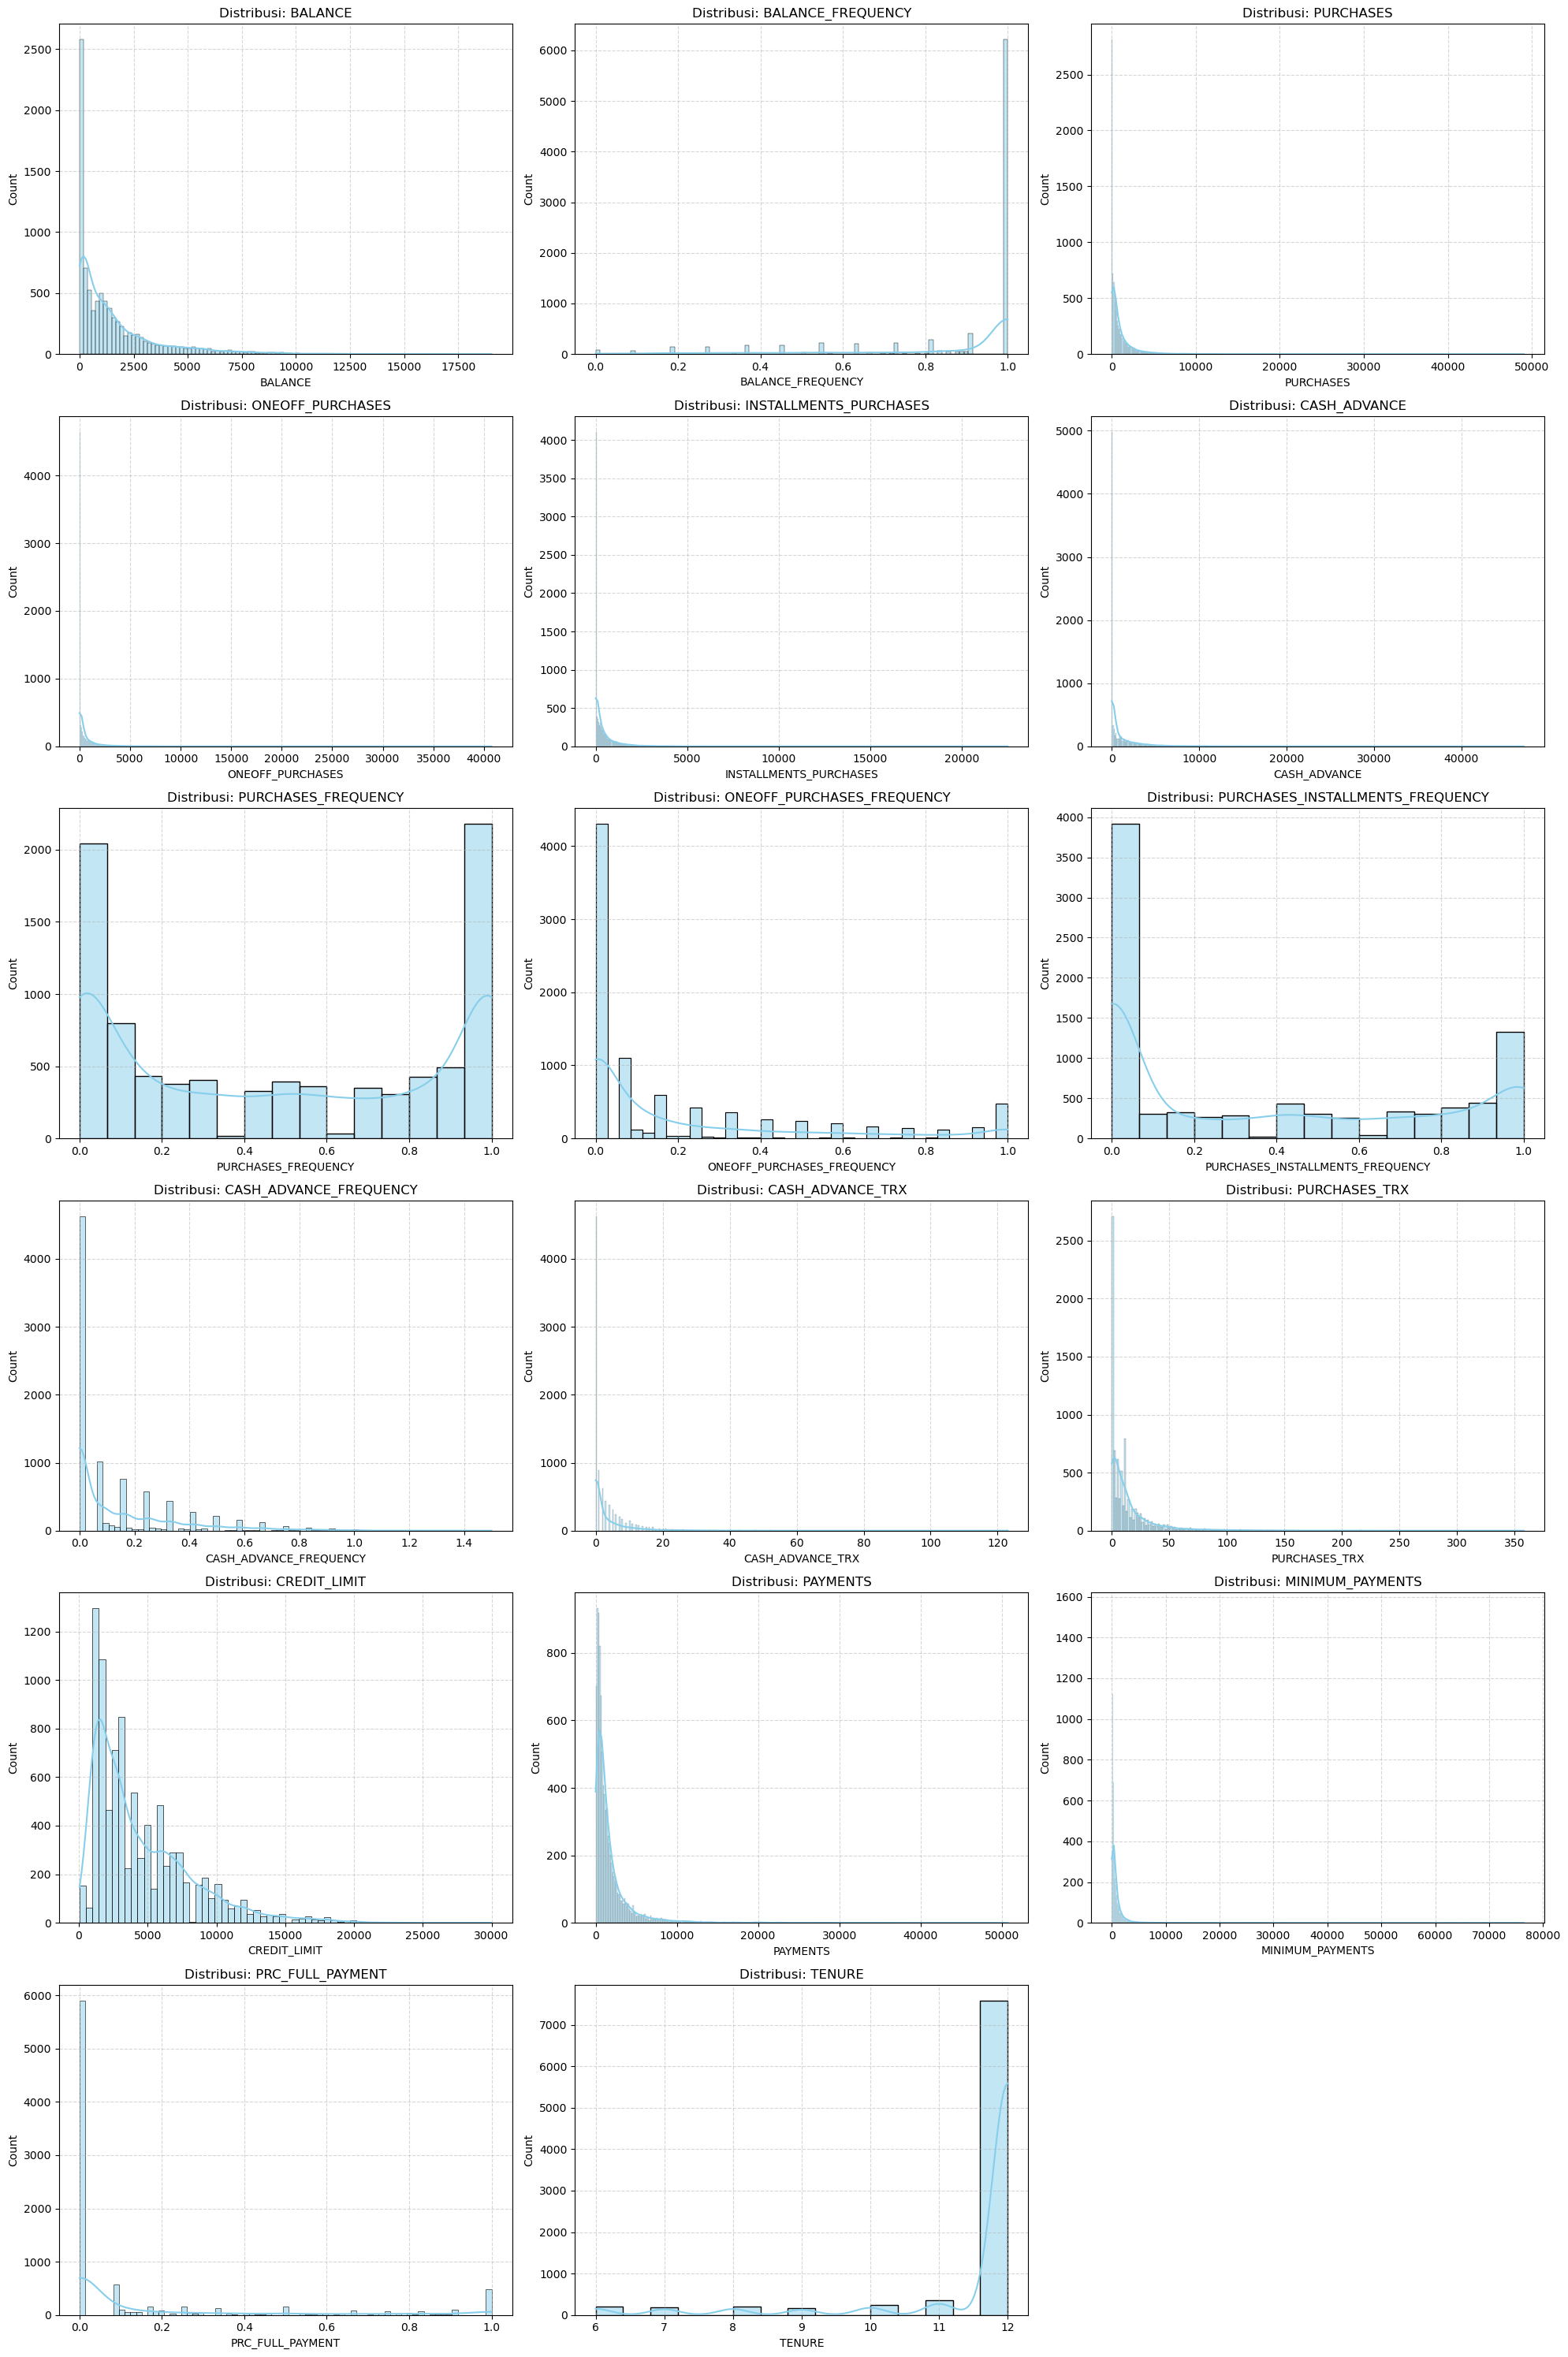

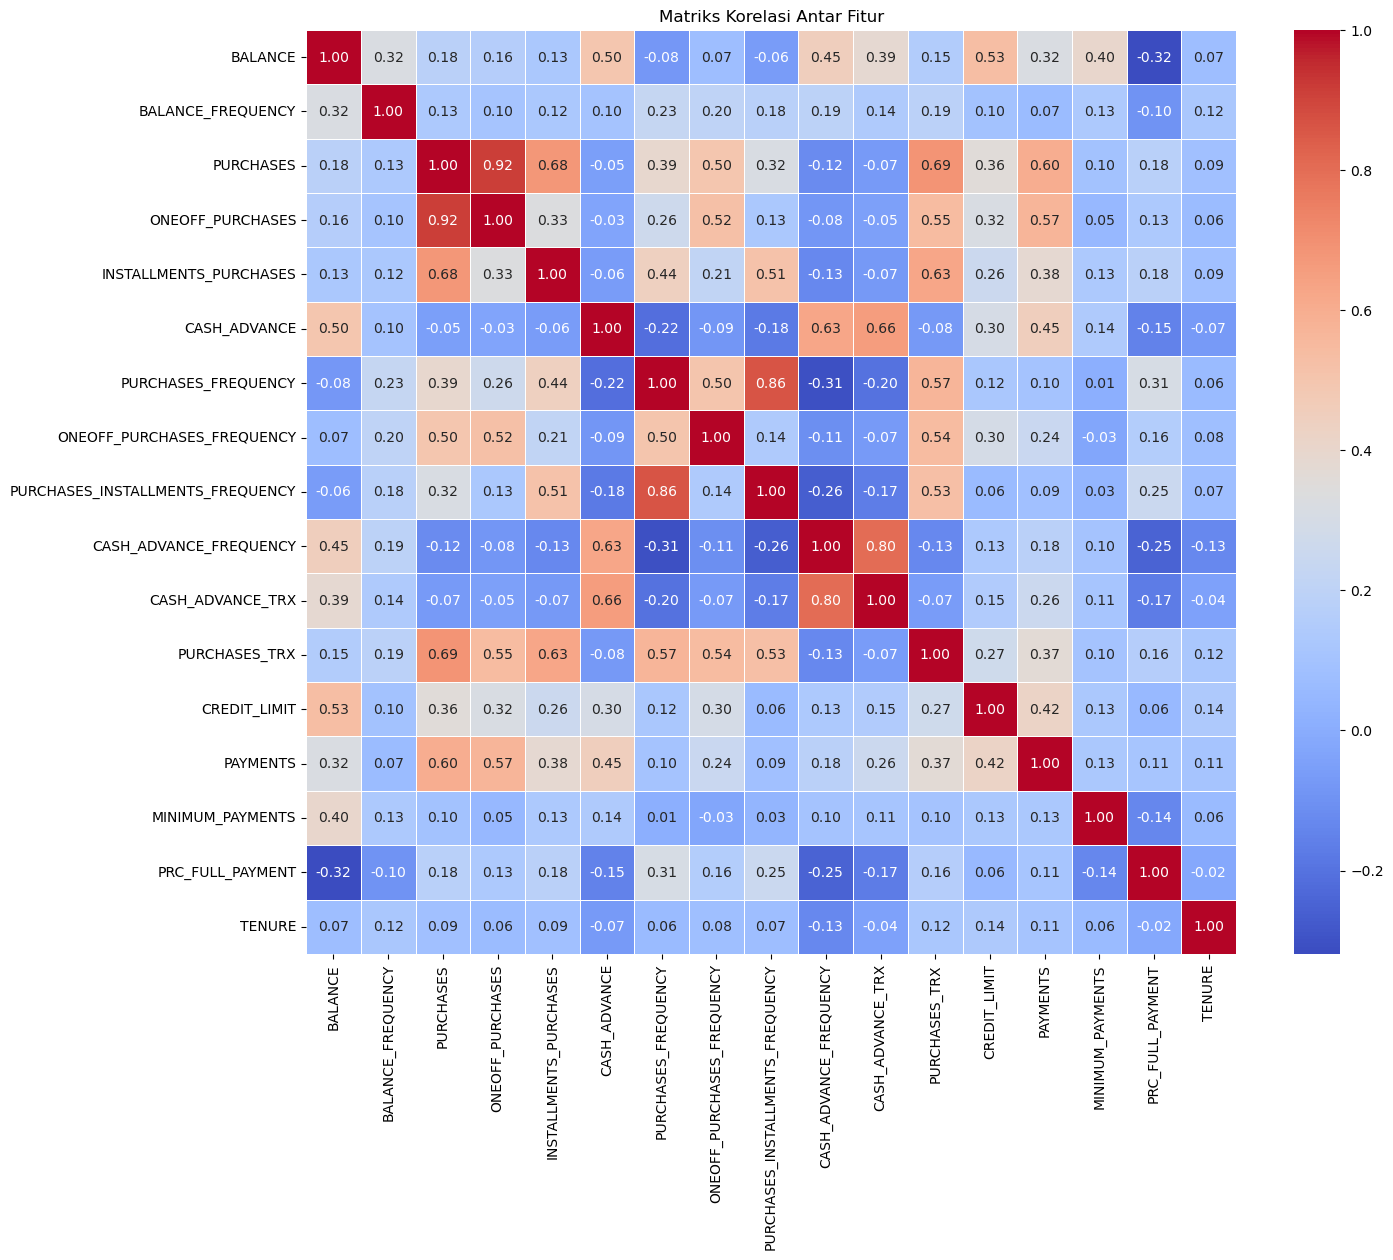

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) ---")

# Pastikan 'df' sudah ada dari tahap cleaning sebelumnya
if 'df' not in locals():
    raise ValueError("Variabel 'df' tidak ditemukan! Harap jalankan Tahap 2 (Cleaning) terlebih dahulu.")

# 1. VISUALISASI DISTRIBUSI (HISTOGRAM)
# Kita ingin melihat bentuk grafik setiap kolom
cols = df.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i+1)
    # Gunakan kde=True untuk melihat garis kurva
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribusi: {col}")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2. VISUALISASI KORELASI (HEATMAP)
# Untuk melihat hubungan antar fitur (misal: apakah Purchases berkorelasi dengan Credit Limit?)
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Matriks Korelasi Antar Fitur")
plt.show()

--- TAHAP 4: FEATURE ENGINEERING & PREPROCESSING ---
-> Fitur baru ditambahkan: CREDIT_USAGE & MIN_PAYMENT_RATIO.
-> Log Transformation selesai (Distribusi data lebih normal).
-> Scaling selesai.
Shape Akhir: (8950, 19)


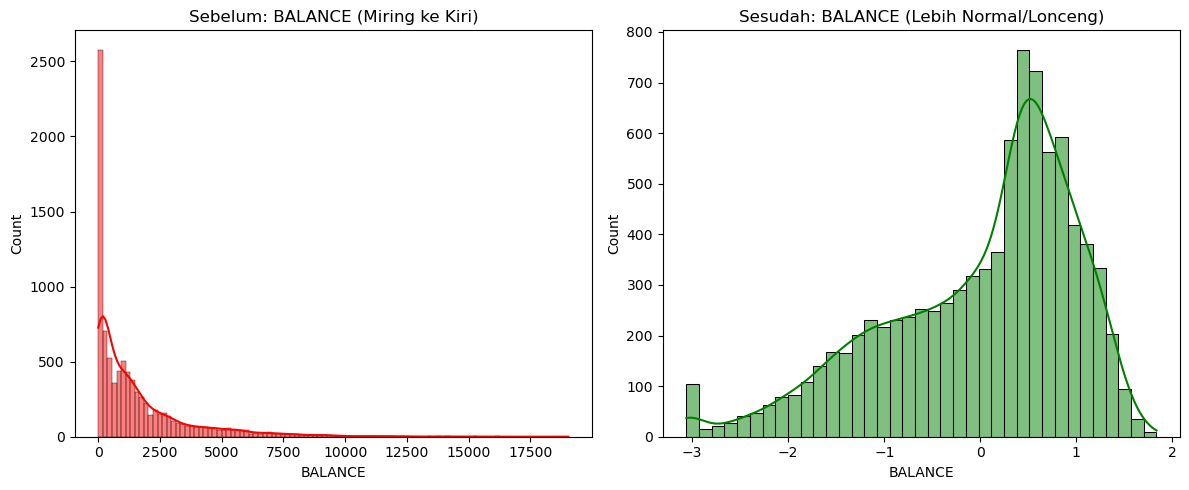

In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("--- TAHAP 4: FEATURE ENGINEERING & PREPROCESSING ---")

# Pastikan 'df' sudah ada dari tahap sebelumnya
if 'df' not in locals():
    raise ValueError("Variabel 'df' hilang. Harap jalankan tahap sebelumnya.")

# 1. FEATURE ENGINEERING (Membuat Fitur Baru)
# Rasio Pemakaian Kredit: Seberapa banyak nasabah memakai limitnya?
# (BALANCE / CREDIT_LIMIT)
df['CREDIT_USAGE'] = df['BALANCE'] / df['CREDIT_LIMIT']

# Rasio Pembayaran: Seberapa rajin nasabah membayar tagihan minimum?
# (PAYMENTS / MINIMUM_PAYMENTS). Ditambah 0.1 agar tidak error pembagian nol.
df['MIN_PAYMENT_RATIO'] = df['PAYMENTS'] / (df['MINIMUM_PAYMENTS'] + 0.1)

print("-> Fitur baru ditambahkan: CREDIT_USAGE & MIN_PAYMENT_RATIO.")

# 2. LOG TRANSFORMATION
# Mengatasi data miring (skewed) yang kita lihat di EDA tadi.
# Kita gunakan log1p (log(x+1)) agar nilai 0 tidak error.
cols_to_transform = df.columns # Semua kolom numerik
df_log = df[cols_to_transform].apply(lambda x: np.log1p(x))
print("-> Log Transformation selesai (Distribusi data lebih normal).")

# 3. SCALING (StandardScaler)
# Menyamakan skala data agar rata-ratanya 0 dan deviasinya 1.
# K-Means sangat butuh ini karena menghitung jarak.
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_log)

# Kembalikan ke bentuk DataFrame agar rapi
df_scaled = pd.DataFrame(df_scaled_array, columns=df.columns)

print("-> Scaling selesai.")
print(f"Shape Akhir: {df_scaled.shape}")

# 4. CEK HASILNYA
# Mari kita lihat perbedaannya pada kolom 'BALANCE'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['BALANCE'], kde=True, color='red')
plt.title("Sebelum: BALANCE (Miring ke Kiri)")

plt.subplot(1, 2, 2)
sns.histplot(df_scaled['BALANCE'], kde=True, color='green')
plt.title("Sesudah: BALANCE (Lebih Normal/Lonceng)")

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("--- TAHAP 4: PREPROCESSING LANJUTAN (REFERENSI BARU) ---")

# Pastikan 'df' sudah bersih (dari tahap cleaning sebelumnya)
# Jika df belum ada, jalankan ulang tahap Load & Cleaning
if 'df' not in locals():
    raise ValueError("Variabel 'df' tidak ditemukan! Harap jalankan Tahap Cleaning dulu.")

# 1. FEATURE SELECTION & SCALING
# Referensi menggunakan RobustScaler yang lebih tahan terhadap outlier
# dibanding StandardScaler biasa.
print("Melakukan Scaling dengan RobustScaler...")
scaler = RobustScaler()

# Kita gunakan semua kolom numerik yang ada
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_scaled = scaler.fit_transform(df[numeric_cols])
df_scaled = pd.DataFrame(df_scaled, columns=numeric_cols)

# 2. DIMENSIONALITY REDUCTION (PCA)
# Referensi menggunakan PCA untuk mengurangi noise dan dimensi data
# Ini sangat membantu K-Means bekerja lebih baik
print("Melakukan Reduksi Dimensi dengan PCA...")
pca = PCA(n_components=2) # Kita ambil 2 komponen utama
pca_2d = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(pca_2d, columns=['PCA1', 'PCA2'])

print("-> Preprocessing Selesai.")
print(f"Shape Data PCA: {df_pca.shape}")



--- TAHAP 4: PREPROCESSING LANJUTAN (REFERENSI BARU) ---
Melakukan Scaling dengan RobustScaler...
Melakukan Reduksi Dimensi dengan PCA...
-> Preprocessing Selesai.
Shape Data PCA: (8950, 2)



--- TAHAP 5: MODELING (K-MEANS) ---
Mencari jumlah cluster optimal...


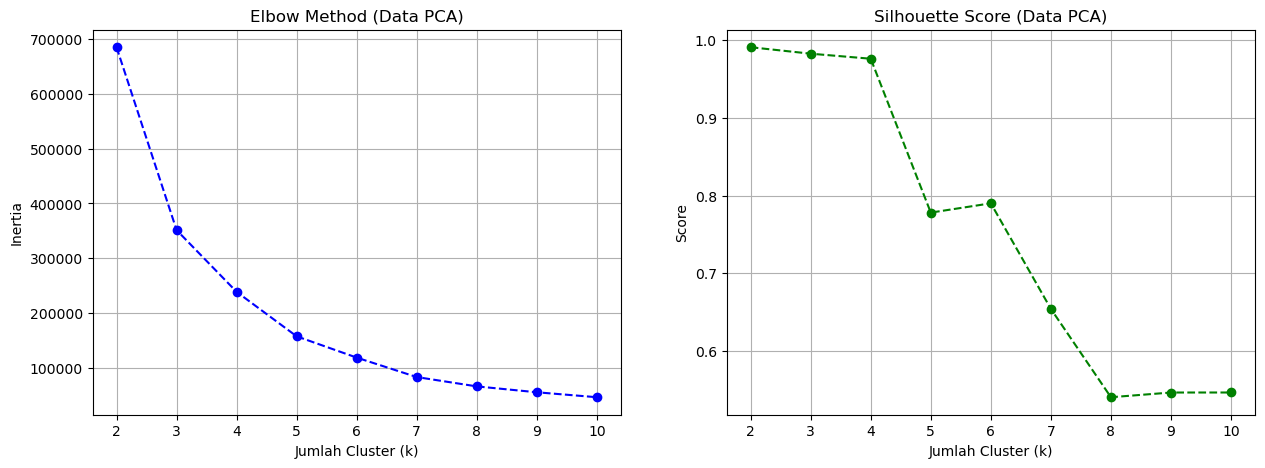

In [19]:

print("\n--- TAHAP 5: MODELING (K-MEANS) ---")

# 3. MENCARI K OPTIMAL (ELBOW & SILHOUETTE)
# Kita terapkan metode ini pada data hasil PCA
inertia = []
silhouette_scores = []
k_range = range(2, 11)

print("Mencari jumlah cluster optimal...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_pca, kmeans.labels_))

# Visualisasi Elbow & Silhouette
plt.figure(figsize=(15, 5))

# Plot Elbow
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method (Data PCA)')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True)

# Plot Silhouette
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--', color='green')
plt.title('Silhouette Score (Data PCA)')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Score')
plt.grid(True)

plt.show()

--- TAHAP 6: FINAL CLUSTERING & INTERPRETASI ---
Menjalankan K-Means dengan k=3...
-> Clustering selesai. Label berhasil ditambahkan.


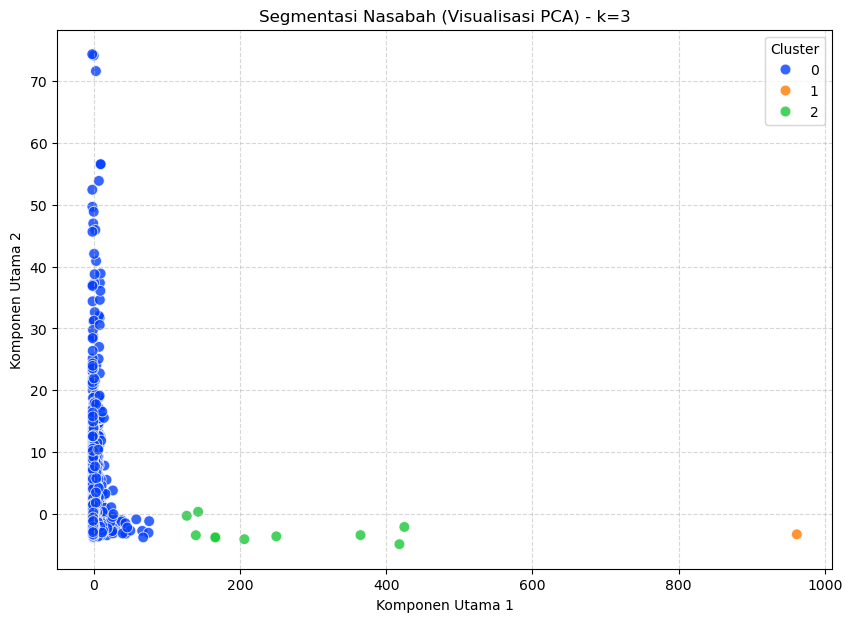


--- PROFIL NASABAH PER CLUSTER (Median) ---


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
CLUSTER,,,,,,,,
0,874.905296,362.36,39.0,89.36,0.000000,3000.0,856.196277,312.343947
1,1.632453,1985.62,0.0,1985.62,0.000000,7500.0,1792.109113,0.261984
2,1.161861,0.00,0.0,0.00,184.886261,3500.0,1060.581856,0.826775



--- ANALISIS SINGKAT ---
[Cluster 0] - 8939 Nasabah
 -> Karakteristik: TRANSACTOR (Seimbang)
[Cluster 1] - 1 Nasabah
 -> Karakteristik: VIP / ACTIVE (Sering Belanja)
[Cluster 2] - 10 Nasabah
 -> Karakteristik: LOW ACTIVITY (Jarang Pakai)


In [20]:
print("--- TAHAP 6: FINAL CLUSTERING & INTERPRETASI ---")

# 1. PILIH JUMLAH CLUSTER (k)
# Ubah angka ini sesuai hasil grafik Elbow/Silhouette Anda (misal 3 atau 4)
k_optimal = 3 
print(f"Menjalankan K-Means dengan k={k_optimal}...")

# Latih model pada data PCA
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_final.fit(df_pca) 

# 2. SIMPAN LABEL KE DATASET
# Kita masukkan label cluster ke data asli untuk dianalisis
df['CLUSTER'] = kmeans_final.labels_
# Kita masukkan juga ke data PCA untuk visualisasi
df_pca['CLUSTER'] = kmeans_final.labels_

print("-> Clustering selesai. Label berhasil ditambahkan.")

# 3. VISUALISASI HASIL CLUSTERING (2D)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='CLUSTER', 
    data=df_pca, 
    palette='bright', 
    s=60, alpha=0.8
)
plt.title(f'Segmentasi Nasabah (Visualisasi PCA) - k={k_optimal}')
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. INTERPRETASI / PROFILING
print("\n--- PROFIL NASABAH PER CLUSTER (Median) ---")
# Kita gunakan MEDIAN agar angka tidak bias oleh outlier 'Sultan'
# Pilih kolom-kolom penting saja untuk dibaca
profiling_cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 
                  'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

cluster_profile = df.groupby('CLUSTER')[profiling_cols].median()
display(cluster_profile)

# Analisis Cepat (Otomatis)
print("\n--- ANALISIS SINGKAT ---")
for c in range(k_optimal):
    n_users = len(df[df['CLUSTER'] == c])
    bal = cluster_profile.loc[c, 'BALANCE']
    pur = cluster_profile.loc[c, 'PURCHASES']
    lim = cluster_profile.loc[c, 'CREDIT_LIMIT']
    
    print(f"[Cluster {c}] - {n_users} Nasabah")
    if bal > 1000 and pur < 500:
        tipe = "REVOLVER (Banyak Saldo/Utang, Jarang Belanja)"
    elif pur > 1000:
        tipe = "VIP / ACTIVE (Sering Belanja)"
    elif bal < 500 and pur < 500:
        tipe = "LOW ACTIVITY (Jarang Pakai)"
    else:
        tipe = "TRANSACTOR (Seimbang)"
    print(f" -> Karakteristik: {tipe}")

--- TAHAP FEATURE ENGINEERING ---
-> Kolom CUST_ID dibuang.
-> Missing values diisi dengan Median.
-> Fitur baru ditambahkan: CREDIT_USAGE, MIN_PAYMENT_RATIO.
-> Melakukan Log Transformation...
-> Melakukan Standard Scaling...

--- Data Siap untuk Clustering ---
Shape Akhir: (8950, 19)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,CREDIT_USAGE,MIN_PAYMENT_RATIO
0,-1.205218,-0.148757,-0.113532,-0.987090,0.394480,-0.930733,-0.746901,-0.732480,-0.674253,-0.724360,-0.810069,-0.579510,-1.447163,-0.824484,-0.829841,-0.556368,0.347262,-1.022796,-0.494131
1,0.948918,0.179616,-1.679855,-0.987090,-1.087454,1.528788,-1.302799,-0.732480,-0.958256,0.699592,0.784603,-1.379210,0.926060,1.065033,0.908184,0.391958,0.347262,0.322182,0.232479
2,0.824993,0.492710,0.600727,1.062022,-1.087454,-0.930733,1.196820,2.466762,-0.958256,-0.724360,-0.810069,0.487865,1.010229,-0.119300,0.450407,-0.556368,0.347262,-0.035495,-0.713623
3,0.624653,-0.857867,0.827499,1.265778,-1.087454,0.564372,-1.014151,-0.363042,-0.958256,-0.213583,-0.123281,-0.874655,1.010229,-4.161996,-0.144271,-0.556368,0.347262,-0.381199,-1.450008
4,0.271260,0.492710,-0.708481,-0.114307,-1.087454,-0.930733,-1.014151,-0.363042,-0.958256,-0.724360,-0.810069,-0.874655,-1.224909,-0.064979,-0.351833,-0.556368,0.347262,0.893219,-0.031476


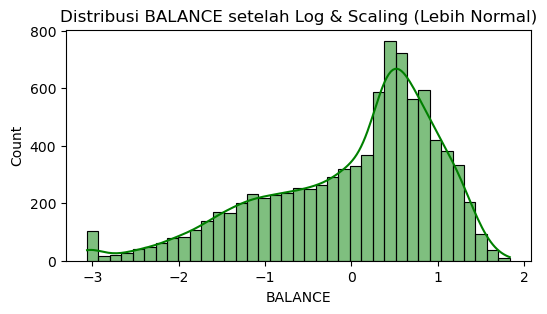

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

print("--- TAHAP FEATURE ENGINEERING ---")

# Gunakan 'df' dari langkah sebelumnya.
# Jika CUST_ID masih ada, kita buang dulu
if 'CUST_ID' in df.columns:
    df = df.drop('CUST_ID', axis=1)
    print("-> Kolom CUST_ID dibuang.")

# 1. HANDLING MISSING VALUES
# Kita isi dengan Median karena data keuangan rentan outlier
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
print("-> Missing values diisi dengan Median.")

# 2. MENAMBAH FITUR BARU (Derived Features)
# Rasio Pemakaian Kredit (Balance / Limit)
df['CREDIT_USAGE'] = df['BALANCE'] / df['CREDIT_LIMIT']

# Rasio Pembayaran (Payments / Min Payments)
# Tambahkan 0.1 agar tidak error division by zero
df['MIN_PAYMENT_RATIO'] = df['PAYMENTS'] / (df['MINIMUM_PAYMENTS'] + 0.1)

print("-> Fitur baru ditambahkan: CREDIT_USAGE, MIN_PAYMENT_RATIO.")

# 3. LOG TRANSFORMATION (Mengatasi Skewness/Kemiringan)
# Kita terapkan Log ke semua kolom numerik agar distribusi lebih normal (lonceng)
# Gunakan log1p (log(x+1)) agar nilai 0 tidak error
print("-> Melakukan Log Transformation...")
df_log = df.apply(lambda x: np.log1p(x))

# 4. SCALING (StandardScaler)
print("-> Melakukan Standard Scaling...")
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_log)

# Ubah kembali ke DataFrame
df_scaled = pd.DataFrame(df_scaled_array, columns=df.columns)

print("\n--- Data Siap untuk Clustering ---")
print("Shape Akhir:", df_scaled.shape)
display(df_scaled.head())

# Cek apakah distribusi sudah lebih rapi (Opsional, cek 1 kolom)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 3))
sns.histplot(df_scaled['BALANCE'], kde=True, color='green')
plt.title("Distribusi BALANCE setelah Log & Scaling (Lebih Normal)")
plt.show()

--- ALGORITMA K-MEANS ---
Silhouette Score (K-Means): 0.2288


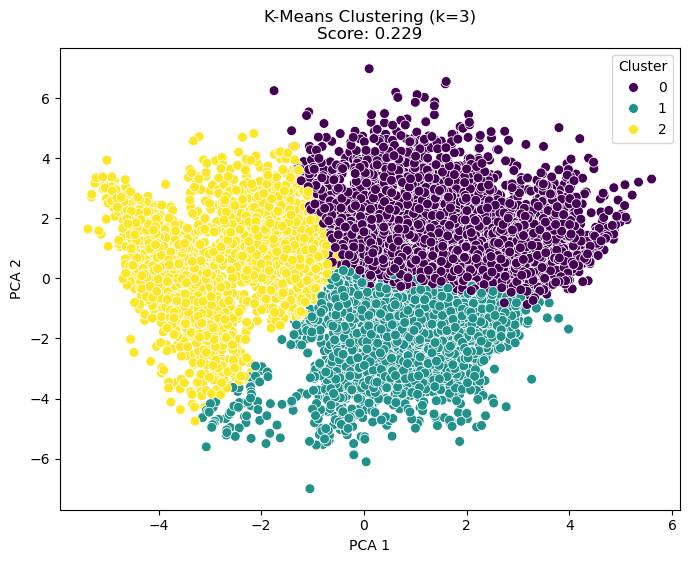

In [28]:
from sklearn.cluster import KMeans

print("--- ALGORITMA K-MEANS ---")

# Konfigurasi
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Training
kmeans_labels = kmeans.fit_predict(df_normalized)

# Evaluasi
score_kmeans = silhouette_score(df_normalized, kmeans_labels)
print(f"Silhouette Score (K-Means): {score_kmeans:.4f}")

# Visualisasi
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca['P1'], y=df_pca['P2'], hue=kmeans_labels, palette='viridis', s=50)
plt.title(f'K-Means Clustering (k={k})\nScore: {score_kmeans:.3f}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

--- ALGORITMA HIERARCHICAL CLUSTERING ---
Silhouette Score (Hierarchical): 0.1714


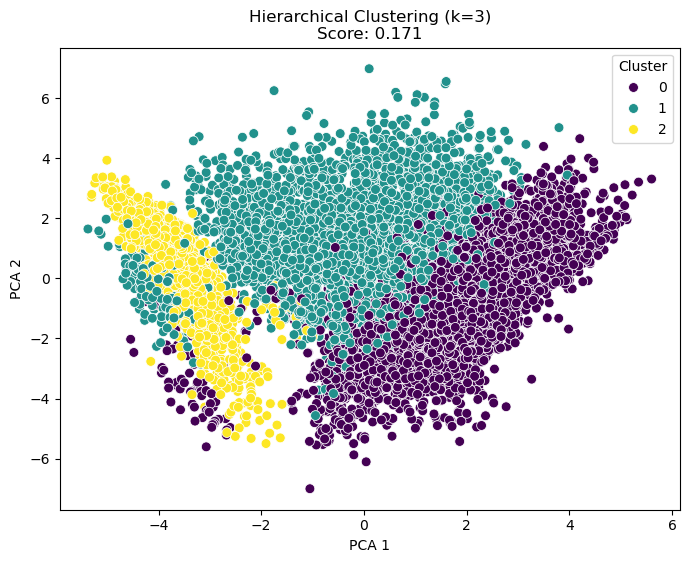

In [27]:
from sklearn.cluster import AgglomerativeClustering

print("--- ALGORITMA HIERARCHICAL CLUSTERING ---")

# Konfigurasi
# linkage='ward' meminimalkan varians dalam cluster
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

# Training
hc_labels = hc.fit_predict(df_normalized)

# Evaluasi
score_hc = silhouette_score(df_normalized, hc_labels)
print(f"Silhouette Score (Hierarchical): {score_hc:.4f}")

# Visualisasi
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca['P1'], y=df_pca['P2'], hue=hc_labels, palette='viridis', s=50)
plt.title(f'Hierarchical Clustering (k=3)\nScore: {score_hc:.3f}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

--- ALGORITMA DBSCAN ---
Silhouette Score (DBSCAN): 0.1623
Jumlah Cluster: 2
Jumlah Noise (Outlier): 110


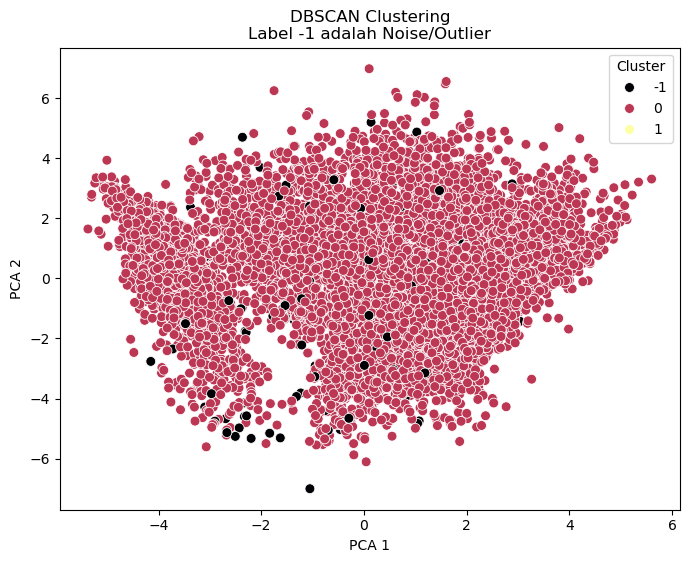

In [26]:
from sklearn.cluster import DBSCAN

print("--- ALGORITMA DBSCAN ---")

# Konfigurasi
# eps: Jarak maksimum antar tetangga (coba ubah ini jika hasilnya cuma 1 warna)
# min_samples: Minimal tetangga untuk dianggap cluster
dbscan = DBSCAN(eps=2.5, min_samples=10)

# Training
dbscan_labels = dbscan.fit_predict(df_normalized)

# Evaluasi (Hanya jika ditemukan lebih dari 1 cluster)
if len(set(dbscan_labels)) > 1:
    score_dbscan = silhouette_score(df_normalized, dbscan_labels)
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)
    
    print(f"Silhouette Score (DBSCAN): {score_dbscan:.4f}")
    print(f"Jumlah Cluster: {n_clusters}")
    print(f"Jumlah Noise (Outlier): {n_noise}")
else:
    print("DBSCAN gagal menemukan cluster. Coba ubah nilai 'eps'.")

# Visualisasi
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca['P1'], y=df_pca['P2'], hue=dbscan_labels, palette='inferno', s=50)
plt.title(f'DBSCAN Clustering\nLabel -1 adalah Noise/Outlier')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

--- PERBANDINGAN AKHIR: K-MEANS vs HIERARCHICAL vs DBSCAN ---


C:\Users\Naufal\AppData\Local\Temp\ipykernel_3920\3543857567.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)



[ TABEL SKOR PERFORMA ]


,Model,Score
0,K-Means,0.228828
1,Hierarchical,0.171382
2,DBSCAN,0.162340


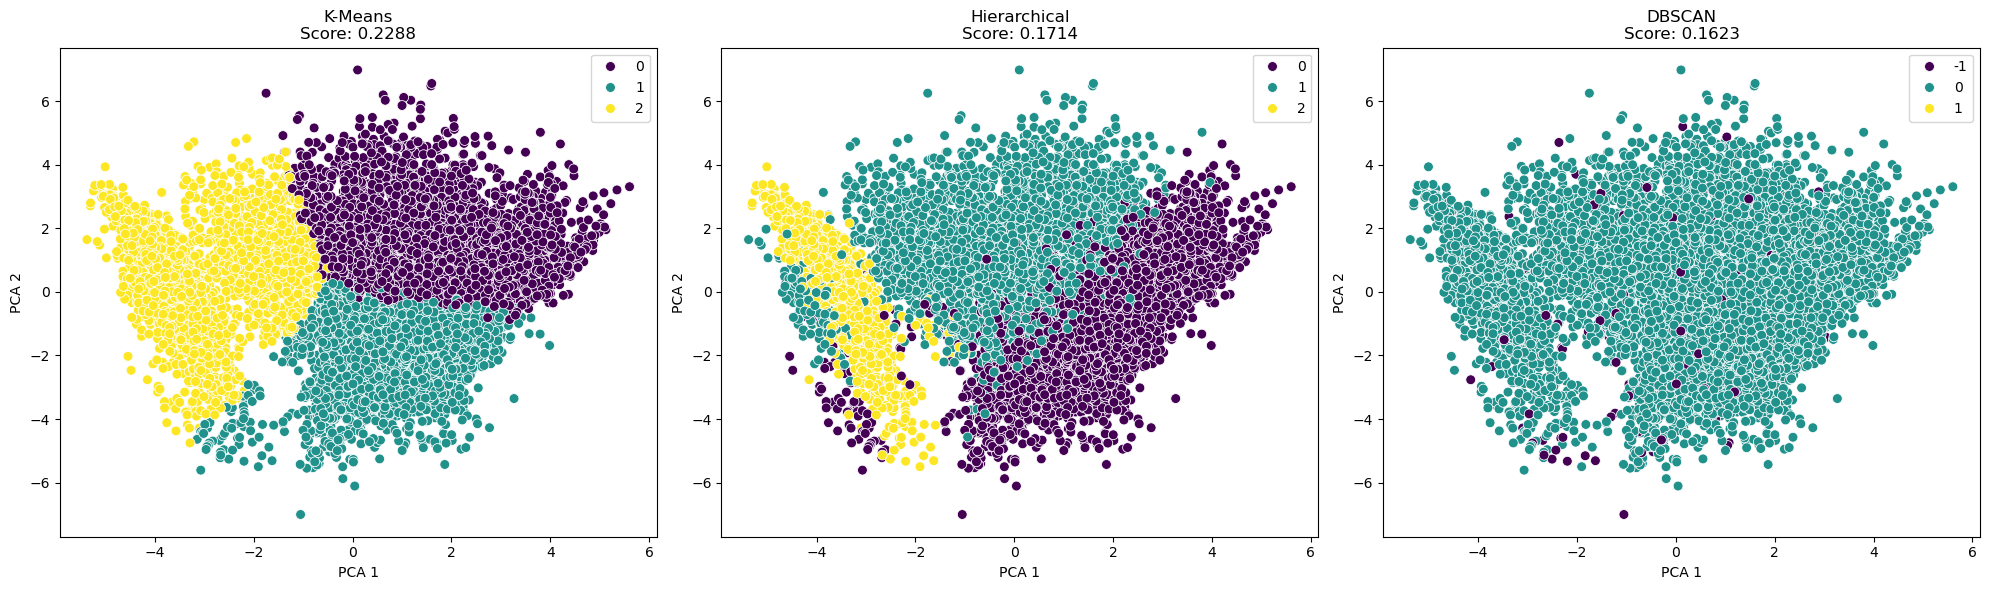


--- KESIMPULAN ---
Berdasarkan Silhouette Score, model terbaik adalah: K-Means (Score: 0.2288)


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import os

print("--- PERBANDINGAN AKHIR: K-MEANS vs HIERARCHICAL vs DBSCAN ---")

# 1. SETUP DATA (Load & Preprocess)
# Cek file mana yang tersedia
filename = 'clusteringmidterm.csv' if os.path.exists('clusteringmidterm.csv') else 'CC GENERAL.csv'
df = pd.read_csv(filename)

# Cleaning sederhana
if 'CUST_ID' in df.columns:
    df = df.drop('CUST_ID', axis=1)
df.fillna(method='ffill', inplace=True)

# Log & Scaling
df_log = df.apply(lambda x: np.log1p(x))
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)
df_normalized = pd.DataFrame(df_scaled, columns=df.columns)

# PCA untuk Visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_normalized)
df_pca = pd.DataFrame(X_pca, columns=['P1', 'P2'])

# --- RUNNING ALGORITMA ---
results = []

# A. K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(df_normalized)
score_km = silhouette_score(df_normalized, labels_km)
results.append({'Model': 'K-Means', 'Score': score_km, 'Labels': labels_km})

# B. Hierarchical (k=3)
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels_hc = hc.fit_predict(df_normalized)
score_hc = silhouette_score(df_normalized, labels_hc)
results.append({'Model': 'Hierarchical', 'Score': score_hc, 'Labels': labels_hc})

# C. DBSCAN (eps=2.5)
db = DBSCAN(eps=2.5, min_samples=10)
labels_db = db.fit_predict(df_normalized)
# Cek apakah DBSCAN berhasil bikin cluster (bukan cuma noise)
if len(set(labels_db)) > 1:
    score_db = silhouette_score(df_normalized, labels_db)
else:
    score_db = -1 # Gagal
results.append({'Model': 'DBSCAN', 'Score': score_db, 'Labels': labels_db})

# --- MENAMPILKAN HASIL ---
# 1. Tabel Perbandingan
comparison_df = pd.DataFrame(results).drop('Labels', axis=1).sort_values(by='Score', ascending=False)
print("\n[ TABEL SKOR PERFORMA ]")
display(comparison_df)

# 2. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, res in enumerate(results):
    sns.scatterplot(
        x=df_pca['P1'], y=df_pca['P2'], 
        hue=res['Labels'], palette='viridis', 
        ax=axes[i], s=50, legend='full'
    )
    axes[i].set_title(f"{res['Model']}\nScore: {res['Score']:.4f}")
    axes[i].set_xlabel('PCA 1')
    axes[i].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

# Kesimpulan Otomatis
winner = comparison_df.iloc[0]
print(f"\n--- KESIMPULAN ---")
print(f"Berdasarkan Silhouette Score, model terbaik adalah: {winner['Model']} (Score: {winner['Score']:.4f})")
if winner['Model'] == 'DBSCAN' and winner['Score'] == -1:
    print("Catatan: DBSCAN gagal menemukan cluster yang valid (mungkin semua dianggap noise).")

--- VISUALISASI CLUSTER DENGAN PCA ---


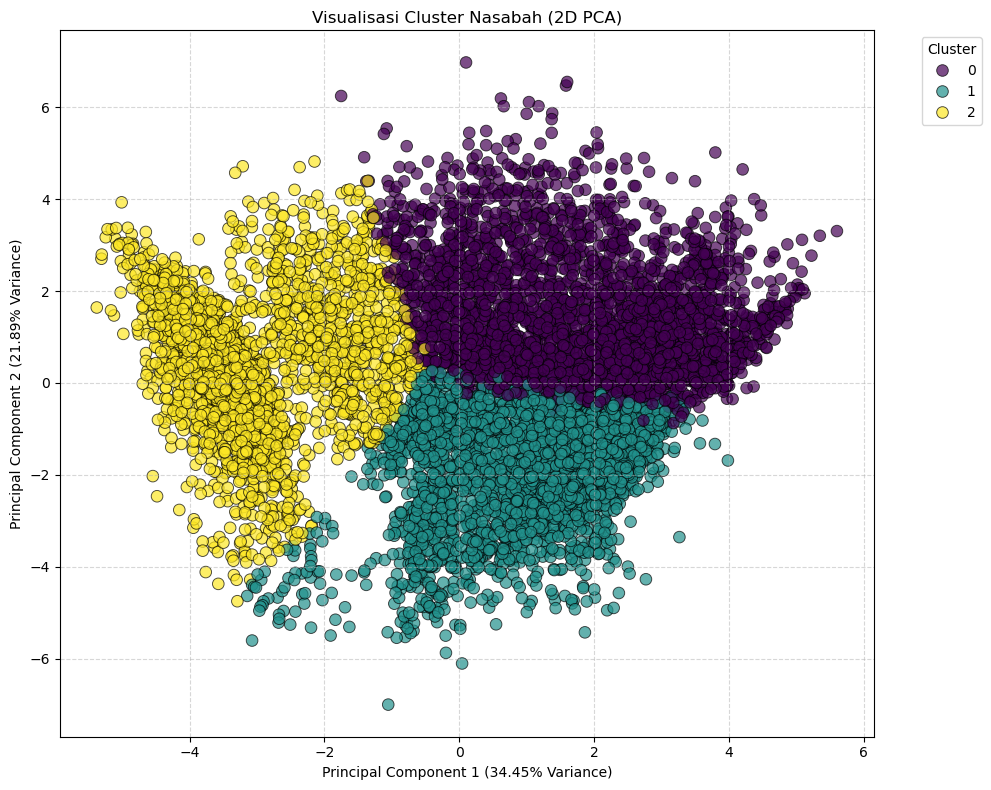

Total Explained Variance (2 Komponen): 56.35%
Catatan: Semakin tinggi variansi yang dijelaskan, semakin akurat representasi 2D ini terhadap data asli.


In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("--- VISUALISASI CLUSTER DENGAN PCA ---")

# 1. TERAPKAN PCA (Reduksi ke 2 Dimensi)
# Kita gunakan data yang sudah dinormalisasi/scaled
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_normalized)

# Buat DataFrame untuk memudahkan plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PCA1', 'PCA2'])

# Tambahkan label cluster dari algoritma yang ingin divisualisasikan
# Contoh: Kita pakai label hasil K-Means (kmeans_labels) dari tahap sebelumnya
pca_df['Cluster'] = kmeans_labels 

# 2. PLOT SCATTER PLOT
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1', 
    y='PCA2', 
    hue='Cluster', 
    data=pca_df, 
    palette='viridis', 
    s=70,           # Ukuran titik
    alpha=0.7,      # Transparansi
    edgecolor='k'   # Garis pinggir titik
)

plt.title('Visualisasi Cluster Nasabah (2D PCA)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- ANALISIS PCA ---
print(f"Total Explained Variance (2 Komponen): {sum(pca.explained_variance_ratio_)*100:.2f}%")
print("Catatan: Semakin tinggi variansi yang dijelaskan, semakin akurat representasi 2D ini terhadap data asli.")

--- CLUSTER INTERPRETATION & PROFILING (FIXED) ---
-> Label berhasil ditambahkan ke DataFrame.

[Profil Nasabah per Cluster - Median]


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
Cluster,,,,,,
0,1310.411507,1445.80,0.000000,5000.0,1616.218055,522.673972
1,59.064314,313.89,0.000000,2500.0,410.798862,157.784568
2,1592.974511,0.00,1340.127945,3000.0,827.318305,533.337236


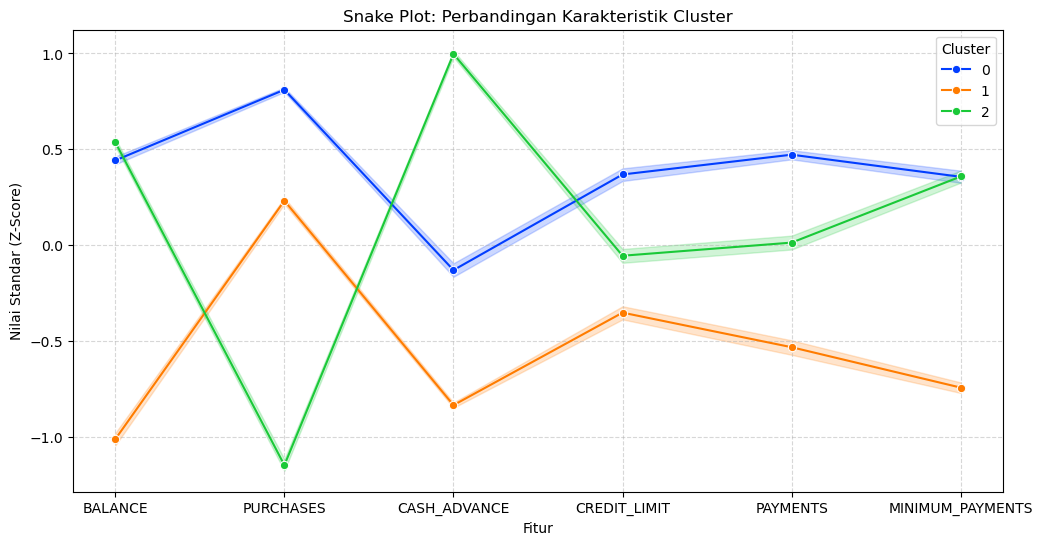


--- KESIMPULAN PROFIL ---
[Cluster 0]
 -> Tipe: 'Big Spender / VIP' (Belanja Tinggi)
[Cluster 1]
 -> Tipe: 'Transactor / Hemat' (Saldo & Belanja Rendah/Sedang)
[Cluster 2]
 -> Tipe: 'Revolver' (Suka Cicil/Saldo Tinggi, Jarang Belanja)


In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

print("--- CLUSTER INTERPRETATION & PROFILING (FIXED) ---")

# 1. PERBAIKAN TIPE DATA (FIX ERROR)
# Cek apakah df_scaled berupa numpy array? Jika ya, ubah ke DataFrame
if 'df_scaled' in locals() and isinstance(df_scaled, np.ndarray):
    print("-> Mengubah df_scaled dari Array ke DataFrame...")
    # Ambil nama kolom dari data asli (kecuali kolom Cluster/CUST_ID jika ada)
    cols = [c for c in df.columns if c not in ['Cluster', 'CUST_ID', 'Label']]
    # Pastikan jumlah kolom cocok
    if df_scaled.shape[1] == len(cols):
        df_scaled = pd.DataFrame(df_scaled, columns=cols)
    else:
        # Fallback jika jumlah kolom beda (jarang terjadi)
        df_scaled = pd.DataFrame(df_scaled)

# 2. RUN K-MEANS & LABELING
# Kita gunakan k=3 (atau sesuaikan dengan hasil analisis Anda)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Latih model
labels = kmeans.fit_predict(df_scaled)

# Masukkan label ke data asli dan data scaled
df['Cluster'] = labels
df_scaled['Cluster'] = labels 

print("-> Label berhasil ditambahkan ke DataFrame.")

# 3. PROFILING STATISTIK (Tabel Median)
print(f"\n[Profil Nasabah per Cluster - Median]")
# Kolom yang ingin dilihat karakteristiknya
numeric_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']
# Pastikan kolom tersebut ada di df
valid_cols = [c for c in numeric_cols if c in df.columns]

profile_table = df.groupby('Cluster')[valid_cols].median()
display(profile_table)

# 4. VISUALISASI "SNAKE PLOT"
# Melt data menjadi format panjang agar bisa di-plot garis
df_melt = pd.melt(
    df_scaled.reset_index(), 
    id_vars=['Cluster'], 
    value_vars=valid_cols, 
    var_name='Fitur', 
    value_name='Nilai (Scaled)'
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melt, x='Fitur', y='Nilai (Scaled)', hue='Cluster', palette='bright', marker="o")

plt.title('Snake Plot: Perbandingan Karakteristik Cluster')
plt.xlabel('Fitur')
plt.ylabel('Nilai Standar (Z-Score)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. INTERPRETASI OTOMATIS
print("\n--- KESIMPULAN PROFIL ---")
for c in range(k):
    # Ambil karakteristik utama (gunakan valid_cols untuk menghindari key error)
    bal = profile_table.loc[c, 'BALANCE'] if 'BALANCE' in profile_table.columns else 0
    pur = profile_table.loc[c, 'PURCHASES'] if 'PURCHASES' in profile_table.columns else 0
    
    print(f"[Cluster {c}]")
    if pur > 1000:
        print(" -> Tipe: 'Big Spender / VIP' (Belanja Tinggi)")
    elif bal > 1000 and pur < 500:
        print(" -> Tipe: 'Revolver' (Suka Cicil/Saldo Tinggi, Jarang Belanja)")
    else:
        print(" -> Tipe: 'Transactor / Hemat' (Saldo & Belanja Rendah/Sedang)")

In [40]:
import pandas as pd

print("\n" + "="*80)
print("INTERPRETASI PROFIL SEMUA CLUSTER (LENGKAP)")
print("="*80)

# 1. Pastikan Kolom Cluster Ada
if 'Cluster' not in df.columns:
    # Jika tidak ada, kita coba ambil dari label k-means terakhir (jika ada di memori)
    if 'kmeans_final' in locals():
        df['Cluster'] = kmeans_final.labels_
        print("-> Label cluster diambil dari model 'kmeans_final'.")
    else:
        print("ERROR: Kolom 'Cluster' tidak ditemukan. Harap jalankan tahap Modeling (K-Means) terlebih dahulu!")

# 2. Hitung Median Global (Sebagai Patokan/Benchmark)
# Kita membandingkan rata-rata cluster dengan rata-rata nasional (seluruh data)
# untuk menentukan apakah cluster tersebut "Tinggi" atau "Rendah".
global_median = df.median(numeric_only=True)

# 3. LOOPING UNTUK SETIAP CLUSTER (0, 1, 2, ...)
# Kode ini akan otomatis berjalan sebanyak jumlah cluster yang ada
unique_clusters = sorted(df['Cluster'].unique())
print(f"Ditemukan {len(unique_clusters)} Cluster: {unique_clusters}")

for cluster_id in unique_clusters:
    # Ambil data khusus untuk cluster ini saja
    cluster_df = df[df['Cluster'] == cluster_id]
    n_nasabah = len(cluster_df)
    persentase = n_nasabah / len(df) * 100
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id}  |  Jumlah: {n_nasabah} Nasabah ({persentase:.1f}%)")
    print(f"{'='*80}")
    
    # --- A. STATISTIK UTAMA (RATA-RATA) ---
    print(f"\n[1] Karakteristik Utama (Rata-rata):")
    print(f"  • Saldo (Balance)      : ${cluster_df['BALANCE'].mean():,.2f}")
    print(f"  • Total Belanja        : ${cluster_df['PURCHASES'].mean():,.2f}")
    print(f"  • Tarik Tunai (Cash)   : ${cluster_df['CASH_ADVANCE'].mean():,.2f}")
    print(f"  • Limit Kredit         : ${cluster_df['CREDIT_LIMIT'].mean():,.2f}")
    print(f"  • Pembayaran (Payment) : ${cluster_df['PAYMENTS'].mean():,.2f}")
    print(f"  • % Bayar Lunas        : {cluster_df['PRC_FULL_PAYMENT'].mean():.1%} (Persentase nasabah bayar full)")
    
    # --- B. POLA BELANJA ---
    # Cek dominasi tipe belanja (Sekali lunas vs Cicilan)
    total_purchases = cluster_df['PURCHASES'].mean() + 1 # +1 biar aman dari pembagian nol
    oneoff_share = cluster_df['ONEOFF_PURCHASES'].mean() / total_purchases
    install_share = cluster_df['INSTALLMENTS_PURCHASES'].mean() / total_purchases
    
    print(f"\n[2] Pola Perilaku:")
    print(f"  • Belanja Langsung     : {oneoff_share:.1%} dari total belanja")
    print(f"  • Belanja Cicilan      : {install_share:.1%} dari total belanja")
    
    # --- C. KESIMPULAN OTOMATIS (PROFILE SUMMARY) ---
    print(f"\n[3] Kesimpulan Profil:")
    
    # Ambil rata-rata cluster ini
    avg_pur = cluster_df['PURCHASES'].mean()
    avg_bal = cluster_df['BALANCE'].mean()
    avg_cash = cluster_df['CASH_ADVANCE'].mean()
    avg_full_pay = cluster_df['PRC_FULL_PAYMENT'].mean()
    
    # Logika Penentuan Label (Bandingkan dengan Global Median)
    # Kita pakai multiplier (misal 1.5x median) agar kriteria "Tinggi" lebih ketat
    is_high_spender = avg_pur > global_median['PURCHASES'] * 1.5
    is_high_balance = avg_bal > global_median['BALANCE'] * 1.5
    is_high_cash = avg_cash > global_median['CASH_ADVANCE'] * 1.5
    is_good_payer = avg_full_pay > 0.15 # Anggap di atas 15% bayar lunas itu lumayan baik
    
    if is_high_spender and is_good_payer:
        print("  ★ TIPE: 'PRIME / VIP CUSTOMER'")
        print("    -> Belanja banyak dan sering bayar lunas. Nasabah paling berharga (Profitable).")
    elif is_high_spender and is_high_balance:
        print("  ★ TIPE: 'REVOLVER SPENDER'")
        print("    -> Belanja banyak tapi saldo menumpuk (nyicil/bunga). Berisiko tapi untung dari bunga.")
    elif is_high_cash:
        print("  ★ TIPE: 'CASH USER'")
        print("    -> Lebih suka tarik tunai daripada belanja barang. Butuh dana likuid.")
    elif not is_high_spender and is_high_balance:
        print("  ★ TIPE: 'REVOLVER (LOW SPEND)'")
        print("    -> Jarang belanja baru, tapi masih bayar utang lama/bunga.")
    elif not is_high_spender and not is_high_balance and not is_high_cash:
        print("  ★ TIPE: 'LOW ACTIVITY / DORMANT'")
        print("    -> Jarang pakai kartu. Saldo rendah, belanja dikit.")
    else:
        print("  ★ TIPE: 'MIDDLE / TRANSACTOR'")
        print("    -> Penggunaan wajar/menengah. Tipe nasabah rata-rata.")
    
    print("\n")


INTERPRETASI PROFIL SEMUA CLUSTER (LENGKAP)
Ditemukan 3 Cluster: [np.int32(0), np.int32(1), np.int32(2)]

CLUSTER 0  |  Jumlah: 3194 Nasabah (35.7%)

[1] Karakteristik Utama (Rata-rata):
  • Saldo (Balance)      : $2,091.84
  • Total Belanja        : $2,299.01
  • Tarik Tunai (Cash)   : $823.32
  • Limit Kredit         : $5,809.90
  • Pembayaran (Payment) : $2,670.63
  • % Bayar Lunas        : 15.7% (Persentase nasabah bayar full)

[2] Pola Perilaku:
  • Belanja Langsung     : 62.8% dari total belanja
  • Belanja Cicilan      : 37.2% dari total belanja

[3] Kesimpulan Profil:
  ★ TIPE: 'PRIME / VIP CUSTOMER'
    -> Belanja banyak dan sering bayar lunas. Nasabah paling berharga (Profitable).



CLUSTER 1  |  Jumlah: 2909 Nasabah (32.5%)

[1] Karakteristik Utama (Rata-rata):
  • Saldo (Balance)      : $238.28
  • Total Belanja        : $472.40
  • Tarik Tunai (Cash)   : $28.74
  • Limit Kredit         : $3,292.47
  • Pembayaran (Payment) : $705.07
  • % Bayar Lunas        : 26.8% (Perse